<a href="https://colab.research.google.com/github/codeBMB/July26_BCCE/blob/main/v2_BCCE2026_Session2_Pandas_and_Plotting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/PyBMB_logo.png" width="150" height="150" />

# BCCE 2026 — Coding for Chemistry Workshop
## Session 2: Working with Data — Pandas, Plotting, and Beer's Law

**Purpose:**
In this notebook you will load, inspect, and visualize spectrophotometric
data for Red 40 (Allura Red AC) — the food dye found in Fanta Strawberry soda.
You will use Python to do the same things you might do in Excel: organize data,
calculate statistics, and make a publication-quality plot.
At the end you will have everything you need to determine the concentration
of Red 40 in Fanta.

**By the end of this notebook you will be able to:**
- Retrieve a data file from GitHub and load it into a pandas DataFrame
- Inspect a DataFrame using `head()`, `shape`, and `describe()`
- Calculate the mean and standard deviation across replicate columns
- Create a scatter plot with axis labels and a title
- Add error bars to show measurement variability
- Export your results to a CSV file

**Libraries:**
* `pandas` — loading and organizing data in tables (DataFrames)
* `matplotlib` — creating plots and graphs

**Status:** BCCE 2026 Workshop — July 2026

**License**

<img src="https://github.com/codeBMB/April26_Rutgers-RCSB/raw/main/images/by-nc-sa.png" width="100"/>
CC BY-NC-SA — free to use and adapt for non-commercial educational purposes with attribution.

---
**Authors:** Wally Novak, Paul Craig, Chris Berndsen, Mike Foster

**Acknowledgements:** Supported by NSF IUSE 2518732 and 2518733.

**Contact:** codingforBMB [at] gmail [dot] com

# 0. How to Run This Notebook

To run a cell, click the **▶ play button** on the left side of the cell.

![run button image](https://github.com/wallynovak/biochemistry_seq_analysis/blob/main/images/run.png?raw=1)

A cell is still running if you see a stop button with a moving circle.
A completed cell shows a number in brackets (e.g. [1]) and a checkmark.

**Always run the cells in order from top to bottom.**
**Run the Setup cell first — everything else depends on it.**

> ⚠️ If you close and reopen the notebook, Python forgets everything.
> Run all cells again from the beginning.

# 1. Setup

Run the cell below to load the two Python libraries we need today.

| Library | What it does |
|---|---|
| `pandas` | Organizes data into tables — Python's version of Excel |
| `matplotlib` | Creates plots and graphs |

> 💡 `import pandas as pd` means we can type `pd.read_csv()` instead of
> `pandas.read_csv()` every time — a convenient shortcut that saves typing.

In [1]:
# Run this cell first — loads all tools needed for this notebook
import pandas as pd
import matplotlib.pyplot as plt

print("✅ pandas and matplotlib loaded successfully!")
print(f"   pandas version:     {pd.__version__}")
print(f"   matplotlib version: {plt.matplotlib.__version__}")

✅ pandas and matplotlib loaded successfully!
   pandas version:     2.2.2
   matplotlib version: 3.10.0


# 2. The Experiment — Red 40 in Fanta Strawberry

## What Is Red 40?

**Red 40** (Allura Red AC, FD&C Red No. 40) is one of the most widely
used synthetic food dyes in the world. It gives Fanta Strawberry, sports
drinks, and many candies their characteristic red color.

Chemically, Red 40 is an azo dye that absorbs visible light most strongly
at **504 nm** — right in the green region of the spectrum, which is why
the solution appears red to our eyes.

---

## Beer's Law

Red 40 obeys **Beer's Law**, which tells us that absorbance is
directly proportional to concentration:

$$A = \varepsilon \cdot b \cdot c$$

where:
- $$A$$ = absorbance (unitless, measured by the spectrophotometer)
- $$\varepsilon$$ = molar absorptivity of Red 40 at 504 nm ≈ **25,900 M⁻¹cm⁻¹**
- $$b$$ = path length = **1 cm** (standard cuvette)
- $$c$$ = concentration (mol/L)

This means a plot of absorbance vs. concentration should be a **straight line**.
That line is your standard curve.

---

## What Was Done in Lab

1. Seven **standard solutions** of Red 40 were prepared at known concentrations
   (0 to 80 µM) and the absorbance of each was measured at 504 nm in triplicate
2. A sample of **Fanta Strawberry** was diluted and its absorbance measured
3. **Goal:** use the standard curve to determine the concentration of
   Red 40 in the original soda

We will return to the Fanta measurement after we have built and inspected
the standard curve.

# 3. Retrieve the Data from GitHub

The standard curve data is stored as a CSV file in the workshop
GitHub repository. We will download it directly into this Colab
session using `urllib` — a built-in Python library for working
with URLs.

**The file is located at:**
`https://github.com/codeBMB/July26_BCCE/blob/main/data/red40_std_curve.csv`

> 💡 Notice that we use `raw.githubusercontent.com` in the code below,
> not `github.com`. This is the direct download link that gives us
> the plain file contents rather than the GitHub webpage that surrounds it.

Run the cell below to download the file and confirm it arrived.

In [2]:
# Download the Red 40 data file from GitHub into this Colab session
import urllib.request
import os

# The raw URL for direct file download — note raw.githubusercontent.com not github.com
# data_url = 'https://raw.githubusercontent.com/codeBMB/July26_BCCE/main/data/red40_std_curve.csv'
data_url = 'https://raw.githubusercontent.com/codeBMB/google_colabs/main/python_colabs/data/red40_std_curve.csv'    ### temporary, use the above when published.

# Create a data folder and download the file into it
os.makedirs('data', exist_ok=True)
urllib.request.urlretrieve(data_url, 'data/red40_std_curve.csv')

print("✅ File downloaded successfully!")
print("   Saved to: data/red40_std_curve.csv")
print()
print("You can see the file in the Files panel (📁 icon on the left).")
print("Click the data folder to find red40_std_curve.csv")

✅ File downloaded successfully!
   Saved to: data/red40_std_curve.csv

You can see the file in the Files panel (📁 icon on the left).
Click the data folder to find red40_std_curve.csv


# 4. Load the Data into a DataFrame

## What Is a DataFrame?

A **DataFrame** is Python's version of a spreadsheet.
- Each **column** has a name
- Each **row** is one observation
- You can do calculations on entire columns at once

That is all you need to know to get started.

## Loading a CSV File

`pd.read_csv()` reads a CSV file and converts it into a DataFrame.
It takes the file path as its argument — the location of the file
in this Colab session.

In [3]:
# Load the CSV file into a pandas DataFrame called df
# pd.read_csv() reads the file and organizes it into a table
df = pd.read_csv('data/red40_std_curve.csv')

print("✅ Data loaded successfully!")

✅ Data loaded successfully!


# 5. First Look at the Data

Three quick commands tell you almost everything you need to know
about a new dataset before you start analyzing it.

Work through each cell below in order.
There is a short question after each one — think about it before moving on.

---

## 5a. `df.head()` — See the first rows

In [4]:
# df.head() shows the first 5 rows of the DataFrame by default
# You can show more rows by passing a number: df.head(10)
display(df.head())

,Concentration_uM,Rep1,Rep2,Rep3
0,0,0.001,0.002,0.000
1,5,0.129,0.128,0.127
2,10,0.264,0.262,0.251
3,20,0.537,0.513,0.522
4,40,1.031,1.027,1.013


**Question:** Look at the Rep1, Rep2, and Rep3 values for the 20 µM row.
Are the three values exactly the same? Should they be?
What does the variation between replicates tell you about the measurement?

---

## 5b. `df.shape` — How big is the dataset?

In [5]:
# df.shape returns two numbers: (number of rows, number of columns)
# It is a property, not a function — no parentheses needed
print(f"DataFrame shape: {df.shape}")
print(f"  → {df.shape[0]} rows  (one per concentration point)")
print(f"  → {df.shape[1]} columns  (Concentration_uM, Rep1, Rep2, Rep3)")

DataFrame shape: (7, 4)
  → 7 rows  (one per concentration point)
  → 4 columns  (Concentration_uM, Rep1, Rep2, Rep3)


**Question:** If we had measured 10 concentration points instead of 7,
what would `df.shape` return? What if we added a fourth replicate column?

---

## 5c. `df.describe()` — Summary statistics

In [6]:
# df.describe() calculates summary statistics for every numeric column
# count  = number of non-missing values
# mean   = average value
# std    = standard deviation
# min/max = smallest and largest values
# 25%, 50%, 75% = quartiles (50% is the median)
display(df.describe().round(4))

,Concentration_uM,Rep1,Rep2,Rep3
count,7.0000,7.0000,7.0000,7.0000
mean,30.7143,0.8070,0.7854,0.7940
std,30.3354,0.8013,0.7683,0.7971
min,0.0000,0.0010,0.0020,0.0000
25%,7.5000,0.1965,0.1950,0.1890
50%,20.0000,0.5370,0.5130,0.5220
75%,50.0000,1.2885,1.2940,1.2580
max,80.0000,2.1410,2.0050,2.1420


**Question:** Look at the `mean` row for Rep1, Rep2, and Rep3.
Are they similar to each other? What would it mean if one replicate
had a much higher mean than the others?

> 💡 `describe()` is your first sanity check on any dataset.
> It immediately flags problems before you do any further analysis.

# 6. Calculate the Mean and Standard Deviation Across Replicates

We have three replicate measurements per concentration point.
Before we can plot the standard curve, we need to collapse
these three columns into two summary columns:

- **Mean absorbance** — the best estimate of the true absorbance
- **Standard deviation** — how much the replicates varied

## The Key Concept: `axis=1`

In pandas, `mean()` and `std()` can work in two directions:

| Command | Direction | Result |
|---|---|---|
| `df[cols].mean(axis=0)` | Down each column ↓ | One number per column |
| `df[cols].mean(axis=1)` | Across each row → | One number per row |

We want **one mean per row** (one per concentration point), so we use `axis=1`.

Think of it this way: `axis=1` collapses the three replicate columns
into a single summary value for each concentration.

In [7]:
# Define a list of the replicate column names
# Using a list makes the code easier to read and modify later
replicate_cols = ['Rep1', 'Rep2', 'Rep3']

# Calculate the MEAN absorbance across the three replicates for each row
# axis=1 means calculate across the columns — one result per row
df['mean_abs'] = df[replicate_cols].mean(axis=1)

# Calculate the STANDARD DEVIATION across replicates for each row
# This tells us how consistent the three measurements were
df['stdev_abs'] = df[replicate_cols].std(axis=1)

# Display the updated DataFrame — notice the two new columns on the right
print("DataFrame updated with mean and standard deviation:")
display(df.round(4))

DataFrame updated with mean and standard deviation:


,Concentration_uM,Rep1,Rep2,Rep3,mean_abs,stdev_abs
0,0,0.001,0.002,0.000,0.0010,0.0010
1,5,0.129,0.128,0.127,0.1280,0.0010
2,10,0.264,0.262,0.251,0.2590,0.0070
3,20,0.537,0.513,0.522,0.5240,0.0121
4,40,1.031,1.027,1.013,1.0237,0.0095
5,60,1.546,1.561,1.503,1.5367,0.0301
6,80,2.141,2.005,2.142,2.0960,0.0788


# 7. Your First Plot — The Standard Curve

Now we have everything we need to plot the standard curve.

## How Matplotlib Works

Every plot in matplotlib follows the same five-step pattern:

1. `plt.figure(figsize=(width, height))` — create a blank canvas
2. `plt.scatter(x, y, ...)` — add data points
3. `plt.xlabel(...)` and `plt.ylabel(...)` — label the axes
4. `plt.title(...)` — add a title
5. `plt.show()` — display the plot

Read every comment in the code below before running it.

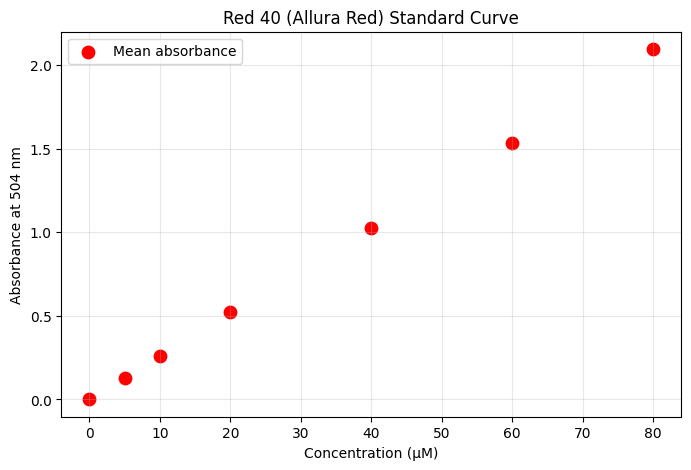

In [8]:
# Plot the Red 40 standard curve

plt.figure(figsize=(8, 5))        # create a canvas 8 inches wide, 5 inches tall

plt.scatter(
    df['Concentration_uM'],       # x-axis: concentration values from the DataFrame
    df['mean_abs'],               # y-axis: mean absorbance values we just calculated
    color='red',                  # color of the data points
    s=80,                         # size of the data points (in points squared)
    label='Mean absorbance'       # label that will appear in the legend
)

plt.xlabel('Concentration (µM)')                  # label for the x-axis
plt.ylabel('Absorbance at 504 nm')                # label for the y-axis
plt.title('Red 40 (Allura Red) Standard Curve')   # plot title
plt.grid(True, alpha=0.3)                         # light gridlines
plt.legend()                                      # display the legend
plt.show()                                        # render and display the plot

**Look at your plot and answer these questions before moving on:**

1. Does the relationship look linear? Is this what Beer's Law predicts?
2. Does the absorbance at 0 µM (the blank) start at or near zero?
   What would it mean if it did not?
3. This plot shows only the **mean** absorbance — it tells us nothing
   about the variability between replicates. How could we show that?

> 💡 You will address question 3 in Exercise 1 below.

# 8. Exercises

You now have the basics. The exercises below each have one specific goal.

**How exercises are formatted in this notebook:**

- `______` — fill in a value, variable name, or column name here
- `# ↓ YOUR CODE HERE` — write a new line of code at this spot
- Hints and answers are available — click to expand them

**Work through the exercises in order — each one builds on the previous.**
Facilitators are circulating — ask for help whenever you need it.

---

## Exercise 1 — Add Error Bars

Your current plot shows only the mean absorbance at each concentration.
**Error bars** show the standard deviation at each point — they give viewers
an honest picture of the measurement uncertainty.

Replace `plt.scatter()` with `plt.errorbar()` to add error bars.

**Key parameters for `plt.errorbar()`:**

| Parameter | What it does | Value to use |
|---|---|---|
| `x` | x-axis data | `df['Concentration_uM']` |
| `y` | y-axis data | `df['mean_abs']` |
| `yerr=` | size of vertical error bars | `df['stdev_abs']` |
| `fmt=` | marker style — `'o'` = circles | `'o'` |
| `capsize=` | width of the horizontal end caps | `4` |

In [ ]:
# Exercise 1: Recreate the standard curve plot with error bars
# ─────────────────────────────────────────────────────────────
# Replace plt.scatter() with plt.errorbar()
# Add yerr= to show the standard deviation at each point
# Fill in every ______ with the correct value or column name
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(8, 5))

# Replace plt.scatter() with plt.errorbar() below
plt.________(
    df['______'],           # x values — concentration column
    df['______'],           # y values — mean absorbance column
    yerr=df['______'],      # error bar size — standard deviation column
    fmt='o',                # marker style: 'o' = circles, no connecting line
    color='red',
    capsize=______,         # width of the horizontal caps — try 4
    label='Mean ± Std Dev'
)

plt.xlabel('Concentration (µM)')
plt.ylabel('Absorbance at 504 nm')
plt.title('Red 40 Standard Curve with Error Bars')
plt.grid(True, alpha=0.3)  # alpha controls the opaqueness of the gridlines
plt.legend()
plt.show()

<details>
<summary>🔍 Click to see the answer</summary>

```python
plt.figure(figsize=(8, 5))

plt.errorbar(
    df['Concentration_uM'],
    df['mean_abs'],
    yerr=df['std_abs'],
    fmt='o',
    color='red',
    capsize=4,
    label='Mean ± Std Dev'
)

plt.xlabel('Concentration (µM)')
plt.ylabel('Absorbance at 504 nm')
plt.title('Red 40 Standard Curve with Error Bars')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
```

Look at the error bars. Are they larger at high or low concentrations?
What does this tell you about the measurement precision?

</details>

---

## Exercise 2 — Explore a Single Column

So far we have applied methods to the whole DataFrame at once.
Pandas also lets you work with one column at a time using:

`df['column_name'].method()`

Complete the three tasks below.
Each one introduces a new pandas tool.

In [ ]:
# Exercise 2: Explore individual columns
# ─────────────────────────────────────────────────────────────

# 2a. Use describe() on just the mean_abs column
#     Fill in the column name inside the square brackets
print("Statistics for the mean absorbance column:")
display(df['______'].describe().round(4))
print()

# 2b. Find the maximum value in the mean_abs column
#     The method is .max() — fill in the column name
print(f"Maximum mean absorbance: {df['______'].max():.4f}")
print()

# 2c. Filter the DataFrame to rows where mean_abs is above 1.0
#     df[df['column'] > value] keeps only rows where the condition is True
#     Fill in the column name and the threshold value
high_abs = df[df['______'] > ______]
print("Rows with mean absorbance above 1.0:")
display(high_abs[['Concentration_uM', 'mean_abs']].round(4))

<details>
<summary>Click to see the answer</summary>

Answer for 2a — describe on one column:
    display(df['mean_abs'].describe().round(4))

Answer for 2b — maximum value:
    print(f"Maximum mean absorbance: {df['mean_abs'].max():.4f}")

Answer for 2c — filter rows:
    high_abs = df[df['mean_abs'] > 1.0]
    display(high_abs[['Concentration_uM', 'mean_abs']].round(4))

</details>

---

## Exercise 3 — Create a New Column

The coefficient of variation (CV%) tells us how consistent
our replicates were, expressed as a percentage of the mean:

    CV% = (standard deviation / mean) x 100

A CV% below 5% is considered good for spectrophotometric measurements.
Above 10% suggests a pipetting problem worth investigating.

Create a new column called cv_percent using the std_abs and
mean_abs columns you already calculated.

The pattern for creating a new column is:
    df['new_column_name'] = expression

In [ ]:
# Exercise 3: Calculate CV% for each concentration point
# ─────────────────────────────────────────────────────────────
# CV% = (std_abs / mean_abs) * 100
# Fill in the two column names in the blanks below
# ─────────────────────────────────────────────────────────────

# ↓ YOUR CODE HERE — write one line to create df['cv_percent']
df['cv_percent'] = (df['______'] / df['______']) * 100

# Display the result
print("CV% for each concentration point:")
display(df[['Concentration_uM', 'mean_abs', 'std_abs', 'cv_percent']].round(2))
print()

# Interpret the CV% values automatically
print("Interpretation:")
for _, row in df.iterrows():
    conc = row['Concentration_uM']
    cv   = row['cv_percent']
    if conc == 0:
        print(f"  {conc:>4} uM: CV% not meaningful for the blank")
    elif cv < 5:
        print(f"  {conc:>4} uM: CV% = {cv:.1f}%  Excellent precision")
    elif cv < 10:
        print(f"  {conc:>4} uM: CV% = {cv:.1f}%  Acceptable — review technique")
    else:
        print(f"  {conc:>4} uM: CV% = {cv:.1f}%  High — check pipetting")

<details>
<summary>Click to see the answer</summary>

Answer:
    df['cv_percent'] = (df['std_abs'] / df['mean_abs']) * 100

The pattern is the same as creating mean_abs and std_abs earlier.
df['new_col'] = expression using existing columns.
This applies the calculation to every row simultaneously — no loop needed.

</details>

---

## Exercise 4 — The Fanta Unknown

Now we can use the standard curve to determine the Red 40 concentration
in Fanta Strawberry.

A sample of Fanta was diluted 1:50 with water and its absorbance
measured at 504 nm. The result was 0.313 AU.

Looking at your standard curve plot, this absorbance falls between
the 10 uM and 20 uM standards. But we can do better than a visual
estimate — we can calculate the exact value using the equation of
a straight line:

    A = slope x [concentration] + intercept

Rearranging to solve for concentration:

    [concentration] = (A - intercept) / slope

We will calculate the slope and intercept using numpy.
Then apply the dilution correction to get the concentration in the original soda.

Note: np.polyfit(x, y, 1) fits a line (degree 1 = linear)
and returns [slope, intercept] as a list.

In [ ]:
# Exercise 4: Use the standard curve to find Red 40 concentration in Fanta
# ─────────────────────────────────────────────────────────────
import numpy as np

# The Fanta measurement
fanta_absorbance = 0.277    # absorbance of Fanta diluted 1:10
fanta_dilution   = 10       # dilution factor

# Step 1: Fit a straight line to the standard curve data
# np.polyfit(x, y, 1) returns [slope, intercept]
# Fill in the two column names for x and y
coeffs    = np.polyfit(df['______'], df['______'], 1)
slope     = coeffs[0]
intercept = coeffs[1]

print(f"Standard curve equation:")
print(f"  Slope:     {slope:.4f}  AU per uM")
print(f"  Intercept: {intercept:.4f}  AU")
print()

# Step 2: Calculate concentration in the DILUTED Fanta
# rearrange:  A = slope * conc + intercept
#         ->  conc = (A - intercept) / slope
# Fill in fanta_absorbance, intercept, and slope in the correct places
conc_diluted = (______ - ______) / ______
print(f"Concentration in diluted Fanta (1:50): {conc_diluted:.2f} uM")
print()

# Step 3: Correct for the dilution to get concentration in the ORIGINAL soda
# ↓ YOUR CODE HERE — multiply conc_diluted by the dilution factor
conc_original = ______

print(f"Concentration in original Fanta: {conc_original:.1f} uM\n")
print(f"Red 40 molecular weight = 496.42 g/mol\n")
print(f"Concentration in original Fanta in mg/L: {conc_original * 496.42 / 1000:.1f} mg/L")

print('''\nDoes the answer seem reasonable?
Typical Red 40 content in brightly colored sodas is 20 to 150 mg/L.
FDA regulations permit up to 300 mg/kg in beverages.''')

<details>
<summary>Click to see the answer</summary>

Step 1 — fit the line:
    coeffs    = np.polyfit(df['Concentration_uM'], df['mean_abs'], 1)
    slope     = coeffs[0]
    intercept = coeffs[1]

Step 2 — concentration in the diluted sample:
    conc_diluted = (fanta_absorbance - intercept) / slope

Step 3 — correct for the dilution:
    conc_original = conc_diluted * fanta_dilution

Does the answer seem reasonable?
Typical Red 40 content in brightly colored sodas is 20 to 150 mg/L.
FDA regulations permit up to 300 mg/kg in beverages.

</details>

---

## Exercise 5 — Annotate the Plot and Export Your Results

Make two additions to your error bar plot from Exercise 1:

Part A: Add a horizontal dashed line at absorbance = 0.313
to show where the Fanta measurement falls on the standard curve.

Part B: Export your complete DataFrame (with mean, std, and CV% columns)
to a CSV file called red40_results.csv and download it.

Useful commands:
    plt.axhline(y=value, linestyle='--', color='gray')   adds a horizontal line
    df.to_csv('filename.csv', index=False)                saves to CSV

In [ ]:
# Exercise 5: Annotate the plot and export the results
# ─────────────────────────────────────────────────────────────

# Part A: Add the Fanta measurement to the error bar plot

fanta_absorbance = 0.277    # absorbance of Fanta diluted 1:10

plt.figure(figsize=(8, 5))

plt.errorbar(
    df['Concentration_uM'],
    df['mean_abs'],
    yerr=df['std_abs'],
    fmt='o',
    color='red',
    capsize=4,
    label='Standard curve (Mean +/- Std Dev)'
)

# Add a horizontal dashed line at the Fanta absorbance
# Fill in the y value and choose a linestyle ('--' = dashed)
plt.axhline(
    y=______,
    linestyle='______',
    color='darkorange',
    linewidth=1.5,
    label='Fanta Strawberry (1:10 dilution)'
)

plt.xlabel('Concentration (uM)')
plt.ylabel('Absorbance at 504 nm')
plt.title('Red 40 Standard Curve with Fanta Unknown')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ─────────────────────────────────────────────────────────────
# Part B: Export the DataFrame to a CSV file
# Fill in the filename — use 'red40_results.csv'
# ─────────────────────────────────────────────────────────────

# ↓ YOUR CODE HERE — one line to save df as a CSV
df.to_csv('______', index=False)

print("Results saved!")
print("To download: Files panel (folder icon) -> red40_results.csv -> three dots -> Download")

<details>
<summary>Click to see the answer</summary>

Part A — add the horizontal line:
    plt.axhline(
        y=0.313,
        linestyle='--',
        color='darkorange',
        linewidth=1.5,
        label='Fanta Strawberry (1:50 dilution)'
    )

Part B — export to CSV:
    df.to_csv('red40_results.csv', index=False)

</details>

# 9. Bridge to the Next Session — Linear Regression

## What You Just Did

In Exercise 4 you used np.polyfit() to fit a line to your data.
This is a form of linear regression — one of the most important
tools in quantitative science.

The next session will go deeper:
- Use scipy.stats.linregress to get slope, intercept, R-squared, and uncertainty
- Plot the best-fit line on top of the data points
- Understand what R-squared tells you about the quality of the fit



# 10. Wrap-Up

## What You Accomplished

In this session you:
- Retrieved a CSV data file from GitHub
- Loaded it into a pandas DataFrame with pd.read_csv()
- Inspected the data using head(), shape, and describe()
- Calculated mean and standard deviation across replicate columns
- Created a scatter plot of the Red 40 standard curve
- Added error bars to show measurement variability
- Explored individual columns using pandas methods
- Created a new column (CV%) from existing columns
- Used the standard curve to determine Red 40 concentration in Fanta
- Annotated a plot with a reference line
- Exported your results to a CSV file

## Python Concepts You Used

| Concept | Where you used it |
|---|---|
| import | Loading pandas and matplotlib |
| DataFrame df | Organizing the standard curve data |
| pd.read_csv() | Loading the CSV file |
| df.head() df.shape df.describe() | Inspecting the data |
| df[cols].mean(axis=1) | Mean across replicates |
| df['new_col'] = ... | Creating new columns |
| df[df['col'] > value] | Filtering rows |
| plt.errorbar() | Plotting with error bars |
| plt.axhline() | Adding a reference line |
| np.polyfit() | Fitting a line to data |
| df.to_csv() | Exporting results |

## Coming Up in the AI Session

You will use Gemini to help you write the scipy.stats.linregress code
from a plain-language prompt, add the best-fit line to your standard
curve plot, and modify AI-generated code to suit your needs.

The key lesson: AI is a powerful coding assistant — but you need
to understand what the code does to use it well.
That is exactly what you built today.

# Optional Challenge — If You Finish Early

## A Second Food Dye

FD&C Blue No. 1 (Brilliant Blue) is another common food dye.
It absorbs at 630 nm with a molar absorptivity of approximately
16,700 per M per cm.

Use the data below to repeat the full analysis:
1. Build a DataFrame from the dictionary
2. Calculate mean, std, and CV%
3. Plot the standard curve with error bars
4. Compare CV% values to the Red 40 data

    blue1_data = {
        'Concentration_uM': [0, 5, 10, 20, 40, 60, 80],
        'Rep1': [0.001, 0.076, 0.158, 0.321, 0.639, 0.944, 1.298],
        'Rep2': [0.003, 0.082, 0.154, 0.334, 0.628, 0.961, 1.271],
        'Rep3': [-0.001, 0.079, 0.163, 0.316, 0.651, 0.937, 1.319],
    }
    df_blue = pd.DataFrame(blue1_data)

Bonus: plot both dyes on the same graph using different colors.
Hint: call plt.errorbar() twice before calling plt.show().